# Thesis Diagrams for RAG-YHCT

This notebook generates architecture and pipeline diagrams for thesis/report usage.

It supports Graphviz when available and falls back to Matplotlib box-arrow diagrams when Graphviz is unavailable.

## Part 1 - Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from IPython.display import Image, SVG, display

GRAPHVIZ_AVAILABLE = False
GRAPHVIZ_IMPORT_ERROR = None

try:
    from graphviz import Digraph
    GRAPHVIZ_AVAILABLE = True
except Exception as exc:
    GRAPHVIZ_IMPORT_ERROR = str(exc)

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() or (p / "README.md").exists():
            return p
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
FIG_DIR = PROJECT_ROOT / "data" / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

EXPORTED_FILES = []

print(f"Project root: {PROJECT_ROOT}")
print(f"Figure output directory: {FIG_DIR}")
print(f"Graphviz available: {GRAPHVIZ_AVAILABLE}")
if not GRAPHVIZ_AVAILABLE and GRAPHVIZ_IMPORT_ERROR:
    print(f"Graphviz import warning: {GRAPHVIZ_IMPORT_ERROR}")

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

Project root: /home/chplay2020/src/vn-yhct-rag/rag-yhct
Figure output directory: /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures
Graphviz available: False
Graphviz import warning: No module named 'graphviz'


In [2]:
def draw_boxes_matplotlib(title, boxes, arrows, out_path, figsize=(15, 4), fontsize=10):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    box_style = dict(boxstyle="round,pad=0.02,rounding_size=0.02",
                     linewidth=1.2, edgecolor="#222222", facecolor="#f5f5f5")

    for b in boxes:
        x, y = b["xy"]
        w, h = b.get("w", 0.12), b.get("h", 0.14)
        patch = FancyBboxPatch((x, y), w, h, **box_style)
        ax.add_patch(patch)
        ax.text(x + w / 2, y + h / 2, b["label"], ha="center", va="center", fontsize=fontsize)

    for a in arrows:
        x1, y1 = a["start"]
        x2, y2 = a["end"]
        label = a.get("label", "")
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", color="#333333", lw=1.4))
        if label:
            mx, my = (x1 + x2) / 2, (y1 + y2) / 2
            ax.text(mx, my + 0.02, label, fontsize=fontsize - 1, ha="center", va="bottom", color="#333333")

    ax.set_title(title, fontsize=13, weight="bold")
    fig.tight_layout()
    fig.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()


def render_graphviz(dot, out_png_path):
    try:
        # Render PNG directly to target stem (Graphviz adds extension).
        rendered = dot.render(filename=out_png_path.stem, directory=str(out_png_path.parent),
                              format="png", cleanup=True)
        final_path = Path(rendered)
        if final_path.exists():
            display(Image(filename=str(final_path)))
            return final_path
    except Exception as exc:
        print(f"Graphviz render failed, fallback to Matplotlib: {exc}")
    return None

## Part 2 - System Overview Diagram

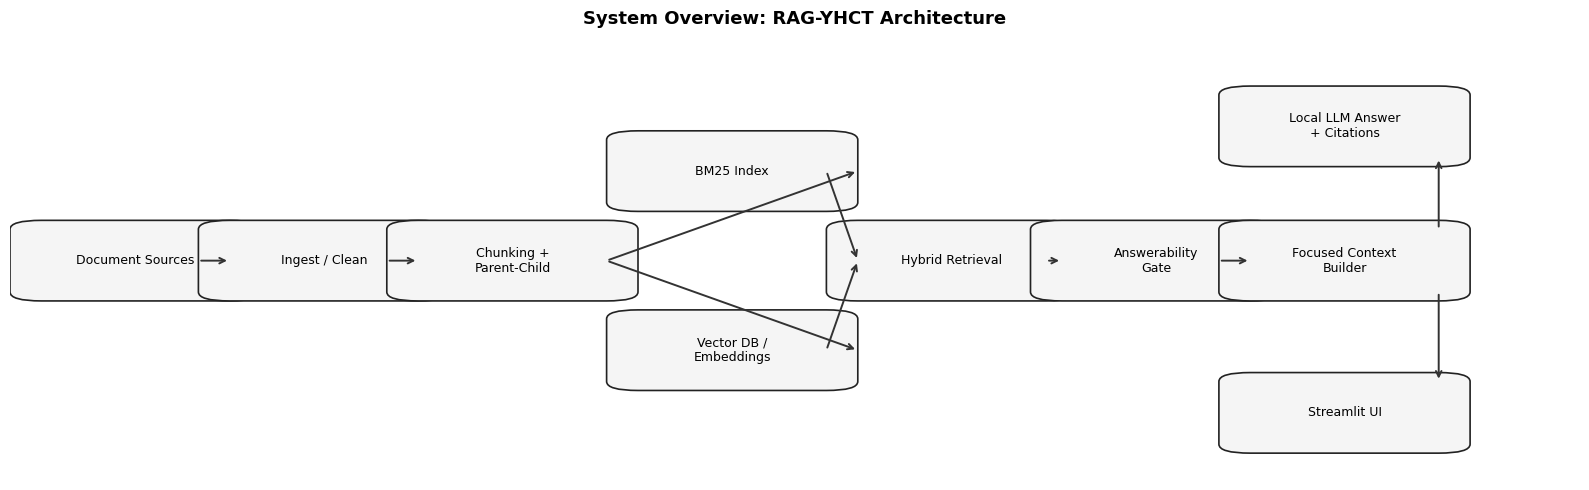

Exported: /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures/system_overview.png


In [3]:
out_system = FIG_DIR / "system_overview.png"

if GRAPHVIZ_AVAILABLE:
    dot = Digraph(comment="System Overview")
    dot.attr(rankdir="LR", fontsize="11")
    dot.attr("node", shape="box", style="rounded,filled", fillcolor="#f5f5f5", color="#222222")

    nodes = [
        ("n1", "Document Sources"),
        ("n2", "Ingest / Clean"),
        ("n3", "Chunking + Parent-Child"),
        ("n4", "BM25 Index"),
        ("n5", "Vector DB / Embeddings"),
        ("n6", "Hybrid Retrieval"),
        ("n7", "Answerability Gate"),
        ("n8", "Focused Context Builder"),
        ("n9", "Local LLM Answer + Citations"),
        ("n10", "Streamlit UI"),
    ]
    for n, label in nodes:
        dot.node(n, label)

    dot.edges([
        ("n1", "n2"),
        ("n2", "n3"),
        ("n3", "n4"),
        ("n3", "n5"),
        ("n4", "n6"),
        ("n5", "n6"),
        ("n6", "n7"),
        ("n7", "n8"),
        ("n8", "n9"),
        ("n9", "n10"),
    ])

    rendered = render_graphviz(dot, out_system)
    if rendered is None:
        GRAPHVIZ_AVAILABLE = False

if not GRAPHVIZ_AVAILABLE:
    boxes = [
        {"xy": (0.02, 0.42), "label": "Document Sources"},
        {"xy": (0.14, 0.42), "label": "Ingest / Clean"},
        {"xy": (0.26, 0.42), "label": "Chunking +\nParent-Child"},
        {"xy": (0.40, 0.62), "label": "BM25 Index"},
        {"xy": (0.40, 0.22), "label": "Vector DB /\nEmbeddings"},
        {"xy": (0.54, 0.42), "label": "Hybrid Retrieval"},
        {"xy": (0.67, 0.42), "label": "Answerability\nGate"},
        {"xy": (0.79, 0.42), "label": "Focused Context\nBuilder"},
        {"xy": (0.79, 0.72), "label": "Local LLM Answer\n+ Citations"},
        {"xy": (0.79, 0.08), "label": "Streamlit UI"},
    ]
    arrows = [
        {"start": (0.14, 0.49), "end": (0.14, 0.49)},
        {"start": (0.13, 0.49), "end": (0.14, 0.49)},
        {"start": (0.26, 0.49), "end": (0.40, 0.69)},
        {"start": (0.26, 0.49), "end": (0.40, 0.29)},
        {"start": (0.52, 0.69), "end": (0.54, 0.49)},
        {"start": (0.52, 0.29), "end": (0.54, 0.49)},
        {"start": (0.66, 0.49), "end": (0.67, 0.49)},
        {"start": (0.78, 0.49), "end": (0.79, 0.49)},
        {"start": (0.91, 0.56), "end": (0.91, 0.72)},
        {"start": (0.91, 0.42), "end": (0.91, 0.22)},
    ]

    # Manually add primary flow arrows cleanly.
    arrows = [
        {"start": (0.12, 0.49), "end": (0.14, 0.49)},
        {"start": (0.24, 0.49), "end": (0.26, 0.49)},
        {"start": (0.38, 0.49), "end": (0.54, 0.69)},
        {"start": (0.38, 0.49), "end": (0.54, 0.29)},
        {"start": (0.52, 0.69), "end": (0.54, 0.49)},
        {"start": (0.52, 0.29), "end": (0.54, 0.49)},
        {"start": (0.66, 0.49), "end": (0.67, 0.49)},
        {"start": (0.77, 0.49), "end": (0.79, 0.49)},
        {"start": (0.91, 0.56), "end": (0.91, 0.72)},
        {"start": (0.91, 0.42), "end": (0.91, 0.22)},
    ]

    draw_boxes_matplotlib(
        title="System Overview: RAG-YHCT Architecture",
        boxes=boxes,
        arrows=arrows,
        out_path=out_system,
        figsize=(16, 5),
        fontsize=9,
    )

EXPORTED_FILES.append(out_system)
print(f"Exported: {out_system}")

**Figure 1.1.** Overview architecture of the retrieval-augmented question answering system, including offline indexing resources and online answer generation components.

## Part 3 - Offline Indexing Pipeline Diagram

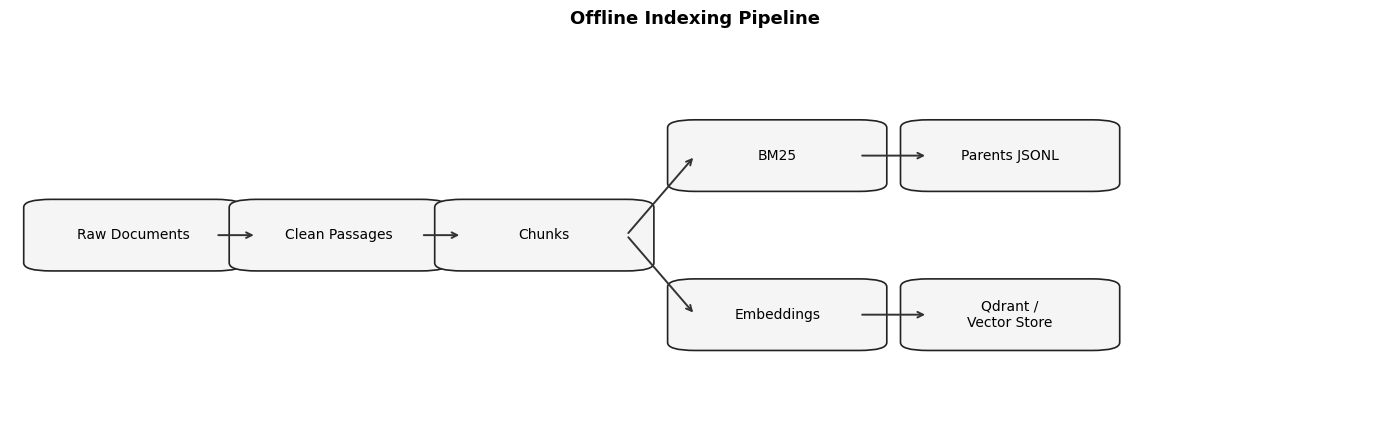

Exported: /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures/offline_pipeline.png


In [4]:
out_offline = FIG_DIR / "offline_pipeline.png"

if GRAPHVIZ_AVAILABLE:
    dot = Digraph(comment="Offline Pipeline")
    dot.attr(rankdir="LR", fontsize="11")
    dot.attr("node", shape="box", style="rounded,filled", fillcolor="#f5f5f5", color="#222222")

    dot.node("d1", "Raw Documents")
    dot.node("d2", "Clean Passages")
    dot.node("d3", "Chunks")
    dot.node("d4", "BM25")
    dot.node("d5", "Embeddings")
    dot.node("d6", "Qdrant / Vector Store")
    dot.node("d7", "Parents JSONL")

    dot.edge("d1", "d2")
    dot.edge("d2", "d3")
    dot.edge("d3", "d4")
    dot.edge("d3", "d5")
    dot.edge("d5", "d6")
    dot.edge("d3", "d7")

    rendered = render_graphviz(dot, out_offline)
    if rendered is None:
        GRAPHVIZ_AVAILABLE = False

if not GRAPHVIZ_AVAILABLE:
    boxes = [
        {"xy": (0.03, 0.42), "label": "Raw Documents"},
        {"xy": (0.18, 0.42), "label": "Clean Passages"},
        {"xy": (0.33, 0.42), "label": "Chunks"},
        {"xy": (0.50, 0.62), "label": "BM25"},
        {"xy": (0.50, 0.22), "label": "Embeddings"},
        {"xy": (0.67, 0.22), "label": "Qdrant /\nVector Store"},
        {"xy": (0.67, 0.62), "label": "Parents JSONL"},
    ]
    arrows = [
        {"start": (0.15, 0.49), "end": (0.18, 0.49)},
        {"start": (0.30, 0.49), "end": (0.33, 0.49)},
        {"start": (0.45, 0.49), "end": (0.50, 0.69)},
        {"start": (0.45, 0.49), "end": (0.50, 0.29)},
        {"start": (0.62, 0.29), "end": (0.67, 0.29)},
        {"start": (0.62, 0.69), "end": (0.67, 0.69)},
    ]

    draw_boxes_matplotlib(
        title="Offline Indexing Pipeline",
        boxes=boxes,
        arrows=arrows,
        out_path=out_offline,
        figsize=(14, 4.5),
        fontsize=10,
    )

EXPORTED_FILES.append(out_offline)
print(f"Exported: {out_offline}")

**Figure 1.2.** Offline indexing workflow from raw documents to BM25 and vector indexes, with parent-child metadata persistence for contextual reconstruction.

## Part 4 - Online Query Pipeline Diagram

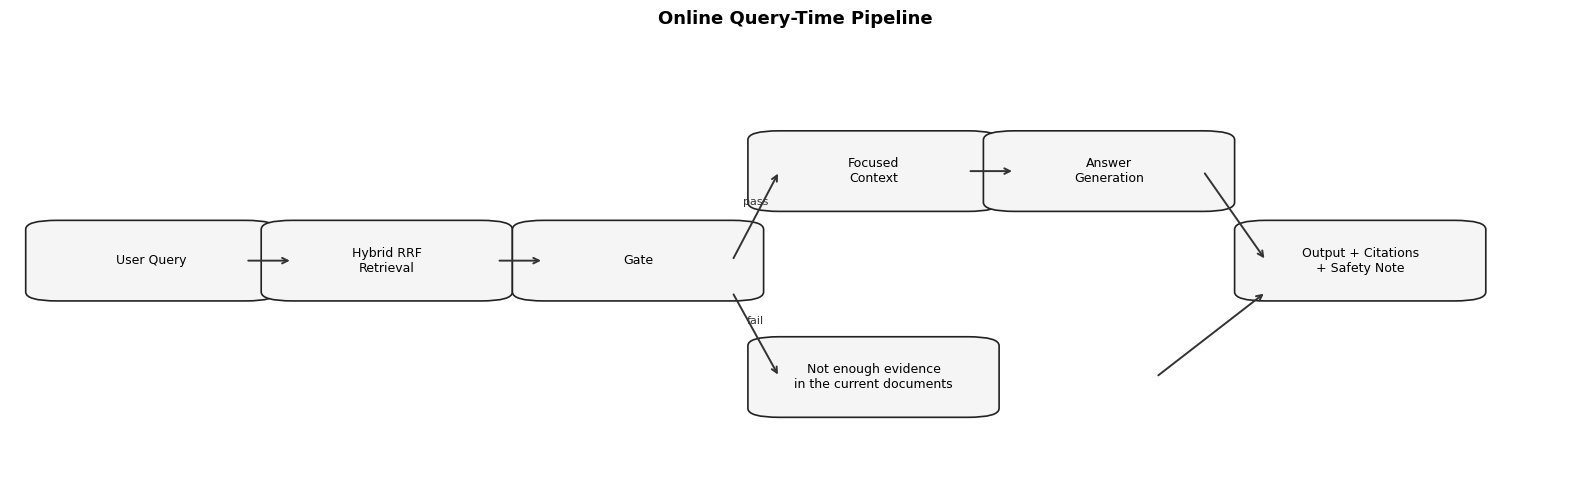

Exported: /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures/online_query_pipeline.png


In [5]:
out_online = FIG_DIR / "online_query_pipeline.png"

if GRAPHVIZ_AVAILABLE:
    dot = Digraph(comment="Online Query Pipeline")
    dot.attr(rankdir="LR", fontsize="11")
    dot.attr("node", shape="box", style="rounded,filled", fillcolor="#f5f5f5", color="#222222")

    dot.node("q1", "User Query")
    dot.node("q2", "Hybrid RRF Retrieval")
    dot.node("q3", "Answerability Gate", shape="diamond")
    dot.node("q4", "Focused Context")
    dot.node("q5", "Answer Generation")
    dot.node("q6", "Output + Citations + Safety Note")
    dot.node("q7", "Not enough evidence in the current documents")

    dot.edge("q1", "q2")
    dot.edge("q2", "q3")
    dot.edge("q3", "q4", label="pass")
    dot.edge("q4", "q5")
    dot.edge("q5", "q6")
    dot.edge("q3", "q7", label="fail")
    dot.edge("q7", "q6")

    rendered = render_graphviz(dot, out_online)
    if rendered is None:
        GRAPHVIZ_AVAILABLE = False

if not GRAPHVIZ_AVAILABLE:
    boxes = [
        {"xy": (0.03, 0.42), "label": "User Query"},
        {"xy": (0.18, 0.42), "label": "Hybrid RRF\nRetrieval"},
        {"xy": (0.34, 0.42), "label": "Gate"},
        {"xy": (0.49, 0.62), "label": "Focused\nContext"},
        {"xy": (0.64, 0.62), "label": "Answer\nGeneration"},
        {"xy": (0.80, 0.42), "label": "Output + Citations\n+ Safety Note"},
        {"xy": (0.49, 0.16), "label": "Not enough evidence\nin the current documents"},
    ]
    arrows = [
        {"start": (0.15, 0.49), "end": (0.18, 0.49)},
        {"start": (0.31, 0.49), "end": (0.34, 0.49)},
        {"start": (0.46, 0.49), "end": (0.49, 0.69), "label": "pass"},
        {"start": (0.61, 0.69), "end": (0.64, 0.69)},
        {"start": (0.76, 0.69), "end": (0.80, 0.49)},
        {"start": (0.46, 0.42), "end": (0.49, 0.23), "label": "fail"},
        {"start": (0.73, 0.23), "end": (0.80, 0.42)},
    ]

    draw_boxes_matplotlib(
        title="Online Query-Time Pipeline",
        boxes=boxes,
        arrows=arrows,
        out_path=out_online,
        figsize=(16, 5),
        fontsize=9,
    )

EXPORTED_FILES.append(out_online)
print(f"Exported: {out_online}")

**Figure 1.3.** Online query-time process with answerability gating, focused context construction, and fail-safe abstention when evidence is insufficient.

## Part 5 - Experiment / Ablation Progression Diagram

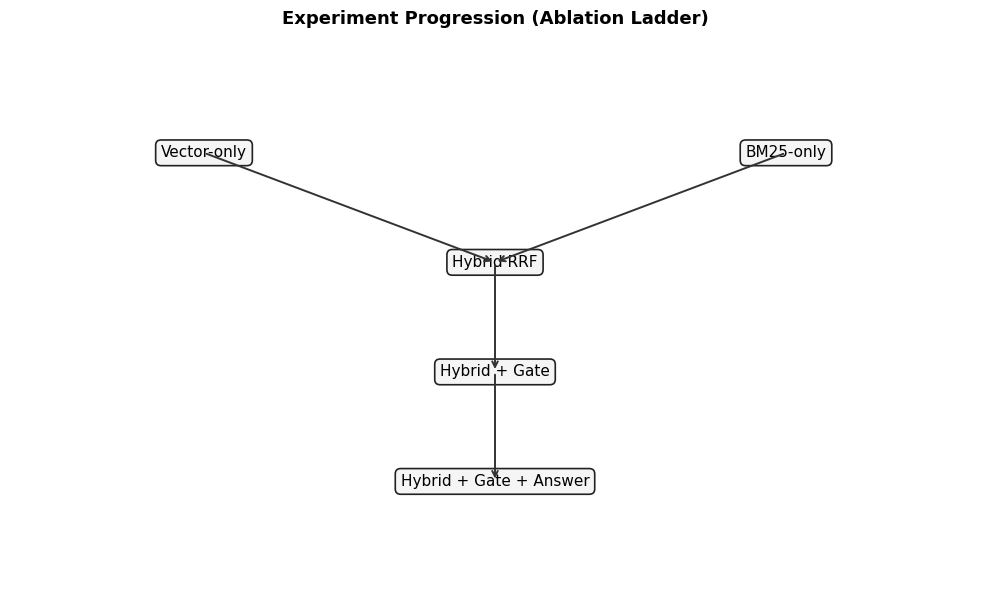

Exported: /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures/experiment_progression.png


In [6]:
out_progress = FIG_DIR / "experiment_progression.png"

if GRAPHVIZ_AVAILABLE:
    dot = Digraph(comment="Experiment Progression")
    dot.attr(rankdir="TB", fontsize="11")
    dot.attr("node", shape="box", style="rounded,filled", fillcolor="#f5f5f5", color="#222222")

    dot.node("p1", "Vector-only")
    dot.node("p2", "BM25-only")
    dot.node("p3", "Hybrid RRF")
    dot.node("p4", "Hybrid + Gate")
    dot.node("p5", "Hybrid + Gate + Answer")

    dot.edge("p1", "p3")
    dot.edge("p2", "p3")
    dot.edge("p3", "p4")
    dot.edge("p4", "p5")

    rendered = render_graphviz(dot, out_progress)
    if rendered is None:
        GRAPHVIZ_AVAILABLE = False

if not GRAPHVIZ_AVAILABLE:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis("off")

    levels = {
        "Vector-only": (0.20, 0.78),
        "BM25-only": (0.80, 0.78),
        "Hybrid RRF": (0.50, 0.58),
        "Hybrid + Gate": (0.50, 0.38),
        "Hybrid + Gate + Answer": (0.50, 0.18),
    }

    for label, (x, y) in levels.items():
        ax.text(x, y, label, ha="center", va="center", fontsize=11,
                bbox=dict(boxstyle="round,pad=0.35", fc="#f5f5f5", ec="#222222", lw=1.2))

    def arr(a, b):
        ax.annotate("", xy=levels[b], xytext=levels[a],
                    arrowprops=dict(arrowstyle="->", lw=1.4, color="#333333"))

    arr("Vector-only", "Hybrid RRF")
    arr("BM25-only", "Hybrid RRF")
    arr("Hybrid RRF", "Hybrid + Gate")
    arr("Hybrid + Gate", "Hybrid + Gate + Answer")

    ax.set_title("Experiment Progression (Ablation Ladder)", fontsize=13, weight="bold")
    fig.tight_layout()
    fig.savefig(out_progress, dpi=220, bbox_inches="tight")
    plt.show()

EXPORTED_FILES.append(out_progress)
print(f"Exported: {out_progress}")

**Figure 1.4.** Experiment progression from single-retriever baselines to the integrated retrieval, gating, and grounded answer-generation configuration.

## Part 6 - Answer Decision Flow Diagram

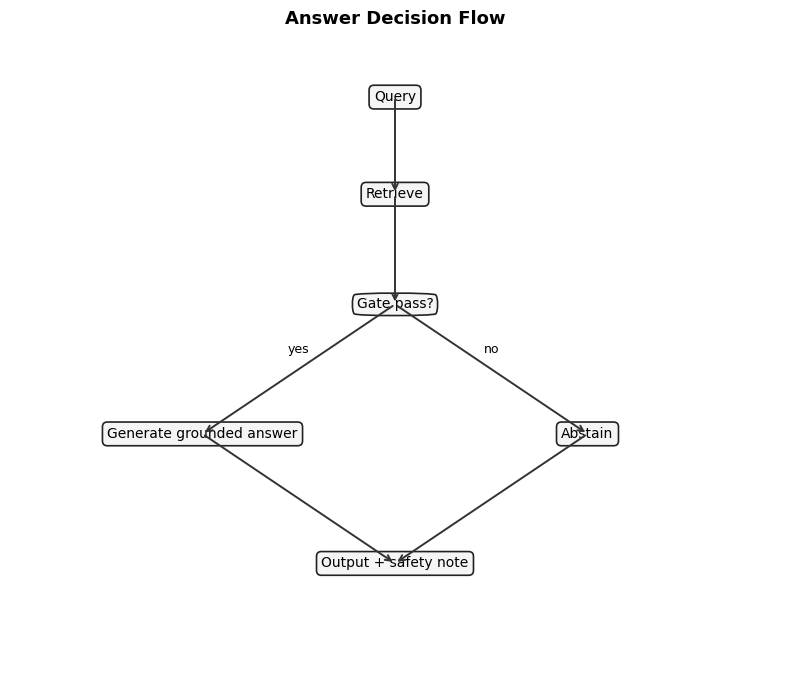

Exported: /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures/answer_decision_flow.png


In [7]:
out_decision = FIG_DIR / "answer_decision_flow.png"

if GRAPHVIZ_AVAILABLE:
    dot = Digraph(comment="Answer Decision Flow")
    dot.attr(rankdir="TB", fontsize="11")
    dot.attr("node", shape="box", style="rounded,filled", fillcolor="#f5f5f5", color="#222222")

    dot.node("a1", "Query")
    dot.node("a2", "Retrieve")
    dot.node("a3", "Gate pass?", shape="diamond")
    dot.node("a4", "Generate grounded answer")
    dot.node("a5", "Abstain")
    dot.node("a6", "Output + safety note")

    dot.edge("a1", "a2")
    dot.edge("a2", "a3")
    dot.edge("a3", "a4", label="yes")
    dot.edge("a3", "a5", label="no")
    dot.edge("a4", "a6")
    dot.edge("a5", "a6")

    rendered = render_graphviz(dot, out_decision)
    if rendered is None:
        GRAPHVIZ_AVAILABLE = False

if not GRAPHVIZ_AVAILABLE:
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.axis("off")

    pos = {
        "Query": (0.5, 0.90),
        "Retrieve": (0.5, 0.75),
        "Gate pass?": (0.5, 0.58),
        "Generate grounded answer": (0.25, 0.38),
        "Abstain": (0.75, 0.38),
        "Output + safety note": (0.5, 0.18),
    }

    for k, (x, y) in pos.items():
        box = dict(boxstyle="round,pad=0.35", fc="#f5f5f5", ec="#222222", lw=1.2)
        if k == "Gate pass?":
            box = dict(boxstyle="round4,pad=0.35", fc="#f5f5f5", ec="#222222", lw=1.2)
        ax.text(x, y, k, ha="center", va="center", fontsize=10, bbox=box)

    def connect(a, b, lbl=""):
        xa, ya = pos[a]
        xb, yb = pos[b]
        ax.annotate("", xy=(xb, yb), xytext=(xa, ya),
                    arrowprops=dict(arrowstyle="->", lw=1.4, color="#333333"))
        if lbl:
            ax.text((xa + xb) / 2, (ya + yb) / 2 + 0.03, lbl, ha="center", va="center", fontsize=9)

    connect("Query", "Retrieve")
    connect("Retrieve", "Gate pass?")
    connect("Gate pass?", "Generate grounded answer", "yes")
    connect("Gate pass?", "Abstain", "no")
    connect("Generate grounded answer", "Output + safety note")
    connect("Abstain", "Output + safety note")

    ax.set_title("Answer Decision Flow", fontsize=13, weight="bold")
    fig.tight_layout()
    fig.savefig(out_decision, dpi=220, bbox_inches="tight")
    plt.show()

EXPORTED_FILES.append(out_decision)
print(f"Exported: {out_decision}")

**Figure 1.5.** Decision logic for grounded response generation, with explicit abstention when retrieval evidence does not satisfy answerability constraints.

## Part 8 - Auto Export

In [8]:
FIG_DIR.mkdir(parents=True, exist_ok=True)

unique_exports = []
seen = set()
for p in EXPORTED_FILES:
    pp = Path(p)
    if pp not in seen:
        seen.add(pp)
        unique_exports.append(pp)

print("Exported figure files:")
for p in unique_exports:
    status = "OK" if p.exists() else "MISSING"
    print(f"- [{status}] {p}")

if not unique_exports:
    print("No figures have been exported yet. Run the diagram cells above first.")

Exported figure files:
- [OK] /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures/system_overview.png
- [OK] /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures/offline_pipeline.png
- [OK] /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures/online_query_pipeline.png
- [OK] /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures/experiment_progression.png
- [OK] /home/chplay2020/src/vn-yhct-rag/rag-yhct/data/reports/figures/answer_decision_flow.png
